# A parallel model for solute transport in a watershed

This notebook presents the parallel capabilities that are available in MODFLOW 6. It is largely based on the hypothetical watershed model from a recent paper on using FloPy to set up workflows for structured and unstructured MODFLOW models (https://doi.org/10.1111/gwat.13327). The following figure gives a nice impression of the properties and layout of this watershed:

<img src="../data/parallel/watershed.jpg" alt="drawing" width="800"/>

In particular, we will use FloPy's pre- and post-processing capabilities for (parallel) MODFLOW 6. Contrary to what is shown in the figure, the spatial discretization of the model will be structured (of type DIS). A special addition to the original example is that instead of using the River Package for all of the streams, we will model the main river branch with the SFR package. A GWT model will be coupled to the flow and in that model the SFT is used to account for the transport of solute in that main river branch. The exercise will demonstrate one of the more recent additions to parallel MODFLOW, i.e., support for the solute and heat transport mover (MVT,MVE) packages as part of the GWT-GWT and GWE-GWE exchanges.

The exercise consists of the following steps:

* Prelude: preprocessing the data
* Set up a single GWF model coupled to a single GWT model for the whole watershed. This model will serve as our ground truth and as a performance benchmark
* Run the single model and plot some results
* Split the model into partitions using the Model Splitter utility available in FloPy
* Run the simulation in parallel and compare results and runtime to the data obtained with the serial run

## Prelude: preprocessing the data

In [ ]:
import os
import sys
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pathlib as pl
from shapely.geometry import LineString

import ipywidgets as widgets
from IPython.display import display

# from flopy
import flopy
from flopy.discretization import StructuredGrid
from flopy.utils.gridintersect import GridIntersect

# local import
sys.path.insert(0, "../data/parallel")  # add Folder_2 path to search list
from parallel_utl import *

# silence all Depr. Warnings
import warnings 
warnings.filterwarnings('ignore', category=DeprecationWarning)

Set up the model directories

In [ ]:
base_dir = "./models/parallel/base"
split_dir = "./models/parallel/split"
if not os.path.isdir(base_dir):
   os.makedirs(base_dir)
if not os.path.isdir(split_dir):
   os.makedirs(split_dir)

Set the cell dimensions. This will determine the number of cells in the grid. You can change it in subsequent runs to increase the number of degrees of freedom of the problem, thereby improving its parallel efficiency.

In [ ]:
dx = dy = 2500.0
nrow = int(Ly / dy) + 1
ncol = int(Lx / dx) + 1

Read in boundary data, the river segments, and the geometry for the SFR reaches

In [ ]:
boundary_polygon = string2geom(geometry["boundary"])
bp = np.array(boundary_polygon)

sfr_segments = string2geom(geometry["streamseg1"])
sfr_segments = sfr_segments[::-1]

riv_geoms = (
    geometry["streamseg2"],
    geometry["streamseg3"],
    geometry["streamseg4"],
)
riv_segments = [string2geom(rg) for rg in riv_geoms]

Plot the geometries

In [ ]:
fig = plt.figure(figsize=figsize)
ax = fig.add_subplot()
ax.set_aspect("equal")

riv_colors = ("cyan", "green", "orange", "red")

ax.plot(bp[:, 0], bp[:, 1], "ro-")
sa = np.array(sfr_segments)
ax.plot(sa[:, 0], sa[:, 1], color="black", lw=0.75, marker="o")

for idx, sg in enumerate(riv_segments):
    sa = np.array(sg)
    ax.plot(sa[:, 0], sa[:, 1], color=riv_colors[idx], lw=0.75, marker="o")

Create a structured grid to work with and restrict it to within the boundary polygon using the `idomain` parameter

In [ ]:
working_grid = StructuredGrid(
    nlay=1,
    delr=np.full(ncol, dx),
    delc=np.full(nrow, dy),
    xoff=0.0,
    yoff=0.0,
    top=np.full((nrow, ncol), 1000.0),
    botm=np.full((1, nrow, ncol), -100.0),
)

set_structured_idomain(working_grid, boundary_polygon)
print("grid data: ", Lx, Ly, nrow, ncol)

Sample the topographic data onto the grid

In [ ]:
fine_topo = flopy.utils.Raster.load("../data/parallel/fine_topo.tif")
top_wg = fine_topo.resample_to_grid(
    working_grid,
    band=fine_topo.bands[0],
    method="linear",
    extrapolate_edges=True,
)

pmv = flopy.plot.PlotMapView(modelgrid=working_grid)
pmv.plot_array(top_wg)
pmv.plot_inactive(color_noflow="white")

Map the river segments onto the grid

In [ ]:
ixs_riv, cellids_riv, lengths_riv = intersect_segments(working_grid, riv_segments)

Intersect SFR segments with the grid

In [ ]:
ixs = GridIntersect(
        working_grid,
    )
ixs_sfr = ixs.intersect(LineString(sfr_segments), sort_by_cellid=False)
cellids_sfr = ixs_sfr['cellids']

Plot the intersections

In [ ]:
intersection_rg = np.zeros(working_grid.shape[1:])
for loc in cellids_sfr:
    intersection_rg[loc] = 1
for loc in cellids_riv:
    intersection_rg[loc] = 1

fig = plt.figure(figsize=figsize)
ax = fig.add_subplot()
pmv = flopy.plot.PlotMapView(modelgrid=working_grid)
ax.set_aspect("equal")
pmv.plot_array(top_wg)
pmv.plot_array(
    intersection_rg,
    masked_values=[
        0,
    ],
    alpha=0.2,
    cmap="Reds_r",
)
pmv.plot_inactive(color_noflow="white")
ax.plot(bp[:, 0], bp[:, 1], "r-")
sa = np.array(sfr_segments)
ax.plot(sa[:, 0], sa[:, 1], "b-")

Set the idomain value to 2 where the river intersects the grid. Further below we will assign drains to simulate the runoff of groundwater discharged at land surface but cells with idomain == 2 will be omitted.

In [ ]:
river_locations = working_grid.idomain[0].copy()
index_sfr = tuple(np.array(list(zip(*cellids_sfr))))
river_locations[index_sfr] = 2
index_riv = tuple(np.array(list(zip(*cellids_riv))))
river_locations[index_riv] = 2
working_grid.idomain = river_locations.reshape(1, nrow, ncol)

Define the number of layers and the thickness of the top layer

In [ ]:
nlay = 3
dv0 = 25.0

Create the SFR data for the reaches, sorted by chainage (or rivermiles in meters...)

In [ ]:
# Build SFR inputs from the stream/grid intersection results
stream_line = LineString(sfr_segments)

# Collect and sort intersections along stream direction
raw_reaches = []
for rec in ixs_sfr:
    i, j = rec["cellids"]
    rlen = float(rec["lengths"])
    midpt = rec["ixshapes"].interpolate(0.5, normalized=True)
    dist = float(stream_line.project(midpt))
    z = fine_topo.sample_point((midpt.x, midpt.y), band=fine_topo.bands[0])
    #cell_top = float(top_wg[i, j])
    cell_top = float(np.asarray(z).squeeze())
    raw_reaches.append((dist, int(i), int(j), rlen, cell_top))
    
# sort by distance along the stream
raw_reaches.sort(key=lambda x: x[0])
raw_reaches[:2]

Stream bed regularization

In [ ]:
# regularize stream bed so adjacent reaches do not become artificially flat
min_stream_slope = 5.0e-4
regularized_reaches = [raw_reaches[0]]
for dist, i, j, rlen, cell_top in raw_reaches[1:]:
    prev_dist, prev_i, prev_j, prev_rlen, prev_top = regularized_reaches[-1]
    dd = max(dist - prev_dist, 1.0)
    max_top = prev_top - min_stream_slope * dd
    regularized_top = min(cell_top, max_top)
    regularized_reaches.append((dist, i, j, rlen, regularized_top))

reaches = regularized_reaches
raw_bed = np.array([rec[4] for rec in raw_reaches], dtype=float)
reg_bed = np.array([rec[4] for rec in reaches], dtype=float)
bed_adjustment = raw_bed - reg_bed

print(f"Applied streambed regularization to {np.count_nonzero(bed_adjustment > 0.0)} reaches")
print(f"Maximum bed lowering: {bed_adjustment.max():.3f} m")

Hydraulic parametrization for SFR

In [ ]:
# SFR Hydraulic parameters (edit if needed)
rwid = 50.0   # reach width
rbth = 1.0    # streambed thickness
rhk = 0.00001   # streambed hydraulic conductivity
man = 0.005   # Manning's n
inflow = 2000.0 # inflow [L^3/T] assigned to the first reach

SFR package data

In [ ]:
# Build MF6 SFR packagedata and connectiondata
nreaches = len(reaches)
sfr_packagedata = []
sfr_connectiondata = []

for rno, (dist, i, j, rlen, cell_top) in enumerate(reaches):
    # streambed top
    rtp = cell_top - 1.0

    # slope from next reach (or previous for last reach)
    if rno < nreaches - 1:
        dist2, _, _, _, top2 = reaches[rno + 1]
        dd = max(dist2 - dist, 1.0)
        dz = max(cell_top - top2, 1e-3)
    elif nreaches > 1:
        dist1, _, _, _, top1 = reaches[rno - 1]
        dd = max(dist - dist1, 1.0)
        dz = max(top1 - cell_top, 1e-3)
    else:
        dd, dz = 1.0, 1e-3

    rgrd = max(dz / dd, 1e-5)
    ncon = int(rno > 0) + int(rno < nreaches - 1)

    # ifno, cellid, rlen, rwid, rgrd, rtp, rbth, rhk, man, ncon, ustrf, ndv
    sfr_packagedata.append(
        (rno, (0, i, j), rlen, rwid, rgrd, rtp, rbth, rhk, man, ncon, 1.0, 0)
    )

    # Connection convention: upstream positive, downstream negative
    conn = [rno]
    if rno > 0:
        conn.append(rno - 1)
    if rno < nreaches - 1:
        conn.append(-(rno + 1))
    sfr_connectiondata.append(conn)

# Stress period data (set inflow at first reach; adjust as needed)
sfr_perioddata = {0: [(0, "inflow", inflow)]}

# Initial stage data (set to streambed + ... for each reach)
sfr_initialstages = [(rno, float(rec[5]) + 1.0) for rno, rec in enumerate(sfr_packagedata)]

print(f"SFR reaches: {nreaches}")
print("Example packagedata row:", sfr_packagedata[0] if nreaches else None)
print("Example connection row:", sfr_connectiondata[0] if nreaches else None)

print(f"Streambed elevation of first reach: {sfr_packagedata[0][5]}")
print(f"Streambed elevation of last reach: {sfr_packagedata[-1][5]}")

Rivers in this model are defined with the DRN package

In [ ]:
leakance = 1.0 / (0.5 * dv0)  # Kv / b  [1/m]

riv_drn_data = build_drain_data(
    working_grid,
    cellids_riv,
    lengths_riv,
    leakance,
    top_wg,
)

And these are the groundwater drains to simulate the discharge at land surface

In [ ]:
gw_discharge_data = build_groundwater_discharge_data(
    working_grid,
    leakance,
    top_wg,
)

Create the top and bot data

In [ ]:
topc = np.zeros((nlay, nrow, ncol), dtype=float)
botm = np.zeros((nlay, nrow, ncol), dtype=float)
dv = dv0
topc[0] = top_wg.copy()
botm[0] = topc[0] - dv

for idx in range(1, nlay):
    dv *= 1.5
    topc[idx] = botm[idx - 1]
    botm[idx] = topc[idx] - dv


for k in range(nlay):
    print(f"thickness layer {k + 1}:", (topc[k] - botm[k]).mean())

Create CHD entries for all cells in the last column (outflow area) of the model that have their bottom below the boundary value

In [ ]:
h_out = 1.0
chd_cells = [(0, int(i), ncol - 1) for i in range(nrow) 
             if working_grid.idomain[0, i,ncol-1] > 0 
             and botm[0, i, ncol-1] < h_out]
spd_chd = {0: [[(c), h_out] for c in chd_cells]}
spd_chd

Create idomain, starting head, and recharge

In [ ]:
# 3D idomain is equal to layered 2D
idomain = np.array([working_grid.idomain[0, :, :].copy() for k in range(nlay)])

# starting head just below land surface
strt = np.array([top_wg.copy() for k in range(nlay)], dtype=float) - 2.0

# uniform recharge
recharge_data = np.zeros_like(top_wg)
recharge_data[:] = 0.000001

# recharge concentration (same shape as recharge/idomain)
rch_conc = np.full((nrow, ncol), 0.0, dtype=float)

Initial concentration

In [ ]:
strt_conc = np.zeros_like(idomain)

## Set up the serial model

This section creates the single-domain model. This will be the reference case against which the parallel run will be judged.

### Why start with serial?

A parallel run is easier to interpret when you know the expected heads, stages, and concentration patterns from a standard run. If the serial model is not trusted, the parallel comparison is not meaningful.

In [ ]:
sim = flopy.mf6.MFSimulation(
    sim_ws=base_dir,
    sim_name="sim",
    exe_name="mf6",
    memory_print_option="summary",
)

# we start with a steady state stress period, then transient 
tdis_data = [(1.0,1,1.0), (10000.0, 10.0, 1.0)]
tdis = flopy.mf6.ModflowTdis(sim, nper=2, perioddata=tdis_data)

# we are solving a water table problem and apply the NEWTON option
gwf = flopy.mf6.ModflowGwf(
    sim,
    modelname="gwf",
    print_input=False,
    save_flows=True,
    newtonoptions="NEWTON UNDER_RELAXATION",
)

imsgwf = flopy.mf6.ModflowIms(
    sim,
    inner_maximum=100,
    outer_maximum=100,
    print_option="SUMMARY",
    outer_dvclose=1e-5,
    inner_dvclose=1e-6,
    linear_acceleration="BICGSTAB",
    under_relaxation="DBD",
    under_relaxation_theta=0.7,
    filename=f"{gwf.name}.ims",
)
sim.register_ims_package(imsgwf, [gwf.name])

dis = flopy.mf6.ModflowGwfdis(
    gwf,
    nlay=nlay,
    nrow=nrow,
    ncol=ncol,
    delr=dx,
    delc=dy,
    idomain=idomain,
    top=top_wg,
    botm=botm,
    xorigin=0.0,
    yorigin=0.0,
)

ic = flopy.mf6.ModflowGwfic(gwf, strt=strt)

chd = flopy.mf6.ModflowGwfchd(
    gwf,
    stress_period_data=spd_chd,
    pname="CHD-1",
)

npf = flopy.mf6.ModflowGwfnpf(
    gwf,
    save_specific_discharge=True,
    icelltype=1,
    k=1.0,
)
sto = flopy.mf6.ModflowGwfsto(
    gwf,
    save_flows=True,
    iconvert=1,
    ss=1e-6,
    sy=0.2,
    steady_state={0: True, 1: False},
    transient={0: False, 1: True},
)
rch = flopy.mf6.ModflowGwfrcha(
    gwf,
    pname="RCH-1",
    auxiliary=["concentration"],
    recharge=recharge_data,
    aux=[rch_conc],
)

sfr = flopy.mf6.ModflowGwfsfr(
    gwf,
    filename="sfr.sfr",
    save_flows=True,
    budget_filerecord="sfr.budget.bin",
    print_input=False,    
    stage_filerecord="stages.sfr.bin",
    nreaches=nreaches,
    packagedata=sfr_packagedata,
    connectiondata=sfr_connectiondata,
    initialstages=sfr_initialstages,
    perioddata=sfr_perioddata,
    pname="SFR-1",
)

drn = flopy.mf6.ModflowGwfdrn(
    gwf,
    stress_period_data=riv_drn_data,
    pname="river",
    filename="drn_riv.drn",
)

drn_gwd = flopy.mf6.ModflowGwfdrn(
    gwf,
    auxiliary=["depth"],
    auxdepthname="depth",
    stress_period_data=gw_discharge_data,
    pname="gwd",
    filename="drn_gwd.drn",
)

oc = flopy.mf6.ModflowGwfoc(
    gwf,
    head_filerecord=f"{gwf.name}.hds",
    budget_filerecord=f"{gwf.name}.cbc",
    saverecord=[("HEAD", "ALL"), ("BUDGET", "ALL")],
    printrecord=[("BUDGET", "ALL")],
)

gwt = flopy.mf6.ModflowGwt(sim, modelname="gwt")

imsgwt = flopy.mf6.ModflowIms(
    sim,
    inner_maximum=100,
    outer_maximum=50,
    print_option="ALL",
    outer_dvclose=1e-5,
    inner_dvclose=1e-6,
    linear_acceleration="BICGSTAB",
    filename=f"{gwt.name}.ims",
)
sim.register_ims_package(imsgwt, [gwt.name])

dis_gwt = flopy.mf6.ModflowGwtdis(
    gwt,
    nlay=nlay,
    nrow=nrow,
    ncol=ncol,
    delr=dx,
    delc=dy,
    idomain=idomain,
    top=top_wg,
    botm=botm,
    xorigin=0.0,
    yorigin=0.0,
)

porosity = 0.2 * np.ones_like(idomain)
mst = flopy.mf6.ModflowGwtmst(
    gwt,
    save_flows=True,
    porosity=porosity,
    pname="mst",
    filename=f"{gwt.name}.mst",
)

ic_gwt = flopy.mf6.ModflowGwtic(gwt, strt=strt_conc)

adv = flopy.mf6.ModflowGwtadv(gwt, scheme="TVD")

dsp = flopy.mf6.ModflowGwtdsp(gwt, alh=0.1, alv=0.01, atv=0.01, ath1=0.01, ath2=0.01)

# Instantiate Streamflow Mass Transport package
strm_conc = 0.0
sft_packagedata = []
for irno in range(nreaches):
    t = (irno, strm_conc)
    sft_packagedata.append(t)

conc_in = 10.0
sft_perioddata = [(0, "INFLOW", conc_in)]
        
sft = flopy.mf6.ModflowGwtsft(
    gwt,
    pname="sft",
    filename="sft.sft",
    flow_package_name="SFR-1",
    print_input=False,
    concentration_filerecord="sft.ucn",
    budget_filerecord="sft.budget.bin",
    packagedata=sft_packagedata,
    reachperioddata=sft_perioddata,
)

ssm = flopy.mf6.ModflowGwtssm(gwt, sources=[["rch-1", "aux", "concentration"]])

oc_gwt = flopy.mf6.ModflowGwtoc(
    gwt,
    concentration_filerecord=f"{gwt.name}.ucn",
    budget_filerecord=f"{gwt.name}.cbc",
    saverecord=[("CONCENTRATION", "ALL"), ("BUDGET", "ALL")],
    printrecord=[("BUDGET", "ALL")],
)

flopy.mf6.ModflowGwfgwt(
    sim,
    exgtype="GWF6-GWT6",
    exgmnamea=gwf.name,
    exgmnameb=gwt.name,
    filename=f"{sim.name}.gwfgwt",
    )


Count the number of active cells. The number of cells gives an idea of the (maximum) parallel efficiency you can expect. We know that for solving a basic groundwater flow problem in parallel, ideally the number of active cells per partition is not smaller than ~50k.

In [ ]:
ncells, nactive = get_simulation_cell_count(sim)
print("nr. of cells:", ncells, ", active:", nactive)

Write the model files

In [ ]:
sim.write_simulation(silent=True)

## Run the serial model

In [ ]:
sim.run_simulation()

From the output to screen in the previous cell, you can read off the `Elapsed run time`, which will be interesting to compare to the parallel run time below.

### Plot results of the serial run
Create a contour map of simulated head (layer 1)

In [ ]:
gwf_model = sim.get_model("gwf")
hds_file = pl.Path(base_dir) / f"{gwf_model.name}.hds"
hds_obj = flopy.utils.HeadFile(hds_file)

# define time for plotting
t_plot = -1
totim = hds_obj.get_times()[t_plot]

head = hds_obj.get_data(totim=totim)

xcc = working_grid.xcellcenters
ycc = working_grid.ycellcenters

h0 = np.ma.masked_where(working_grid.idomain[0] < 1, head[0])

fig, ax = plt.subplots(figsize=figsize)
cf = ax.contourf(xcc, ycc, h0, levels=20, cmap="viridis")
cs = ax.contour(xcc, ycc, h0, levels=20, colors="k", linewidths=0.4)
ax.clabel(cs, inline=True, fontsize=7, fmt="%.1f")

ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"Head contour map (layer 1, t={totim})")
plt.colorbar(cf, ax=ax, label="Head", shrink=0.35)
plt.tight_layout()
plt.show()

Plot distance to groundwater (depth to water table) as a plan view

In [ ]:
fig, ax = plt.subplots(figsize=figsize)
ax.set_aspect("equal")

# Calculate depth to water table (top elevation - head)
depth_to_water = top_wg - head[0]

pmv = flopy.plot.PlotMapView(modelgrid=working_grid, ax=ax, layer=0)
pa = pmv.plot_array(depth_to_water, cmap="RdYlBu_r")
pmv.plot_inactive(color_noflow="white")

cbar = plt.colorbar(pa, ax=ax, label="Depth to Water Table (m)", shrink=0.35)
ax.plot(bp[:, 0], bp[:, 1], "k-", linewidth=1.5, label="Domain boundary")
ax.set_title(f"Distance to Groundwater (t={totim})")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.legend()
plt.tight_layout()
plt.show()

Generate a cross section along the x direction

In [ ]:
# for generating the cross section
y_target = 51000

In [ ]:
row_idx = int(np.argmin(np.abs(ycc[:, 0] - y_target)))
y_sel = float(ycc[row_idx, 0])

gwf_model = sim.get_model("gwf")

# read head at last time
hds_file = pl.Path(base_dir) / f"{gwf_model.name}.hds"
hds_obj = flopy.utils.HeadFile(hds_file)
head = hds_obj.get_data(totim=totim)

# read specific discharge from budget output at same time
cbc_file = pl.Path(base_dir) / f"{gwf_model.name}.cbc"
cbc_obj = flopy.utils.CellBudgetFile(cbc_file)
spdis = cbc_obj.get_data(text="DATA-SPDIS", totim=totim)[0]
qx, qy, qz = flopy.utils.postprocessing.get_specific_discharge(spdis, gwf_model)

# plot cross section
fig, ax = plt.subplots(figsize=(8,4))
xsect = flopy.plot.PlotCrossSection(model=gwf_model, ax=ax, line={"row": row_idx})

pc = xsect.plot_array(head, cmap="viridis")
xsect.plot_grid(lw=0.2, color="0.6")
xsect.plot_inactive(color_noflow="white")
xsect.plot_vector(qx, qy, qz, normalize=True, color="k", hstep=2, kstep=1)

plt.colorbar(pc, ax=ax, label="Head")
ax.set_title(f"Cross section at y={y_sel:.1f} (requested {y_target:.1f}), time={totim}")
ax.set_xlabel("x")
ax.set_ylabel("elevation")
plt.show()

Check the river stages against the bed level for the SFR package

In [ ]:
chainage = np.cumsum([val[2] for val in sfr_packagedata])
stage_file = pl.Path(base_dir) / "stages.sfr.bin"
stage_obj = flopy.utils.HeadFile(stage_file, text="stage")
stage = np.asarray(stage_obj.get_data(totim=totim)).squeeze()

n = min(len(chainage), stage.size)

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(chainage[:n], stage[:n], "o-", lw=1.2, ms=3, label="Stage")
ax.set_xlabel("Chainage (m)")
ax.set_ylabel("River stage (m)")
ax.set_title(f"SFR stage vs chainage (t={totim})")
ax.grid(True, alpha=0.3)

bedlevel = np.asarray([rec[5] for rec in sfr_packagedata], dtype=float)
n_bed = min(len(chainage), bedlevel.size)

ax.plot(chainage[:n_bed], bedlevel[:n_bed], "s-", lw=1.0, ms=3, label="Bed level")
ax.legend()
plt.show()


## Split the model to prepare for parallel execution

Everything below this point is about turning one physically consistent model into several communicating submodels and running it in parallel.

### Some things to keep in mind

- Partitions should be chosen with both hydrology and workload in mind.
- A good split not only balances active cells, but it should also minimize the interface between the models.
- Exchange packages become the glue between submodels. The Model Splitter will automatically generate exchanges and the (geometrical) connection data that goes with it. Alternatively, you could build a parallel model from scratch yourself as a set of models connected through exchanges. Be careful when setting up the exchanges yourself: it's easy to make an error in the configuration, for example, connecting cells that are not adjacent or passing the wrong orientation. Unfortunately, it's very hard to catch that but it will definitely degrade your results.
- A split model differs from the serial base only in terms of the global numbering of the cells. And both can be run with the serial version of the software. Because the difference is no more than a permutation of the rows and columns of the system matrix, the results will be equal within the solver tolerance. This equivalence is one of the strengths of the parallel workflow: start with a serial model, split it and run it again with regular MODFLOW 6, if that all works out then speed up by distributing the workload over multiple cores using the extended version of the software.

***
### A consideration

A useful partition is not just balanced. It also avoids creating unnecessary communication across the strongest physical connections in the model. Imagine splitting a large two layer model, with dimensions 2x1000x1000. Would you prefer to split this horizontally, i.e. by layer with one model for all cells in layer 1 and one model for all cells in layer 2, or is it better to split it vertically so that all exchanges are horizontal?
***

### Model Splitter
FloPy has a relatively new tool to help you split an existing model into an arbitrary number of submodels. This way you can split it to run optimally on the hardware (number of cores) you have available. This is the Model Splitter:

In [ ]:
from flopy.mf6.utils.model_splitter import Mf6Splitter

The following function generates a splitting mask such that the stream enters and leaves a domain partition only once

In [ ]:
# Build a y-axis-aligned partition mask (vertical split lines) for any npartitions
def get_custom_splitting_mask(nparts):

    active = working_grid.idomain[0] > 0

    # active-cell count per column (so partitions are balanced by active cells)
    active_per_col = active.sum(axis=0)
    cum_active = np.cumsum(active_per_col)
    total_active = int(cum_active[-1])

    # target cumulative counts for partition boundaries
    targets = [k * total_active / nparts for k in range(1, nparts)]
    cut_cols = [int(np.searchsorted(cum_active, t, side="right")) for t in targets]

    # enforce strictly increasing cut indices
    for k in range(1, len(cut_cols)):
        cut_cols[k] = max(cut_cols[k], cut_cols[k - 1] + 1)
    cut_cols = [min(c, working_grid.ncol - 1) for c in cut_cols]

    # assign partition ids by column bands (boundaries run along y axis)
    mask_yaxis = np.zeros((working_grid.nrow, working_grid.ncol), dtype=int)
    start = 0
    for pid, stop in enumerate(cut_cols + [working_grid.ncol]):
        mask_yaxis[:, start:stop] = pid
        start = stop

    print("cut columns:", cut_cols)
    print("partition ids:", np.unique(mask_yaxis))
    print("active cells per partition:", [int(((mask_yaxis == p) & active).sum()) for p in range(nparts)])

    return mask_yaxis

Define the number of partitions here and split the model

In [ ]:
npartitions = 8
splitter = Mf6Splitter(sim)
mask = get_custom_splitting_mask(npartitions)
#mask = splitter.optimize_splitting_mask(nparts=npartitions)
split_sim = splitter.split_multi_model(mask)
split_sim.set_sim_path(split_dir)

The output of the previous cell should give you an idea of the balance.

For this notebook, we will run n partitions on n cores. MODFLOW will automatically distribute the groundwater flow models across the available cores, and then assign the solute transport models accordingly. However, in case you would like to distribute the models differently, e.g. by assigning two models to core #1 and three models to core #2 or some other combination, there is the HPC input file to the simulation NAM file that let's you do that:

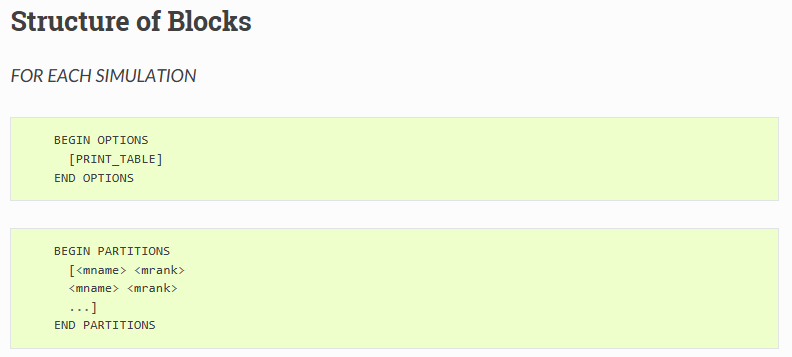

(above image from the MODFLOW IO guide)

It's important to understand and check the final partitioning. The following code will create a plan view of the splitted domain and shows how the river runs through it

In [ ]:
# Plot domain partitions on the original grid, masking inactive cells
partitions = np.asarray(mask)
active = working_grid.idomain[0] > 0
partitions_masked = np.ma.masked_where(~active, partitions)

fig, ax = plt.subplots(figsize=figsize)
ax.set_aspect("equal")

pmv = flopy.plot.PlotMapView(modelgrid=working_grid, ax=ax, layer=0)
pa = pmv.plot_array(partitions_masked)
pmv.plot_inactive(color_noflow="white")
cbar = plt.colorbar(pa, ax=ax, shrink=0.35)

# label each partition at its active-cell centroid
for pid in np.unique(partitions[active]):
    rr, cc = np.where((partitions == pid) & active)
    if rr.size == 0:
        continue
    xc = float(np.mean(xcc[rr, cc]))
    yc = float(np.mean(ycc[rr, cc]))
    ax.text(
        xc,
        yc,
        f"{int(pid)}",
        ha="center",
        va="center",
        fontsize=10,
        weight="bold",
        color="black",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7),
        zorder=5,
    )

# boundary
ax.plot(bp[:, 0], bp[:, 1], "k-", lw=1.2, label="Domain boundary")

# SFR line geometry
sxy = np.asarray(stream_line.coords)
ax.plot(sxy[:, 0], sxy[:, 1], color="blue", lw=1.5, label="SFR", zorder=4)

cbar.set_label("Partition ID")

ax.set_title("Domain partitions (active cells only)")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.legend()
plt.tight_layout()
plt.show()

Let's save the order of partitions as we follow the river downstream, this will be needed below to plot our results

In [ ]:
# Partition IDs ordered from upstream -> downstream using SFR reach distances
partitions = np.asarray(mask)

# reaches entries: (dist, i, j, rlen, cell_top), already sorted by dist
reach_dist = np.array([rec[0] for rec in reaches], dtype=float)
reach_pid = np.array([int(partitions[rec[1], rec[2]]) for rec in reaches], dtype=int)

# Use first (minimum) stream distance in each partition as its upstream position
pid_min_dist = {pid: float(np.min(reach_dist[reach_pid == pid])) for pid in np.unique(reach_pid)}

# Requested index array: first = most upstream, last = most downstream (outflow side)
partition_idx_up_to_down = np.array(
    sorted(pid_min_dist, key=pid_min_dist.get),
    dtype=int
)

print("partition_idx_up_to_down:", partition_idx_up_to_down)

NB: support for MVE and MVT packages on Exchanges in parallel mode is a very recent addition to MODFLOW and only available in the development version. The model splitter in FloPy is currently being extended to support these features. To use it in this class, nonetheless, we have a small workaround inserting the MVT entries 'by hand' as follows:

In [ ]:
gwf_xgfs = [x for x in split_sim.name_file.exchanges.array if x[0] == "GWF6-GWF6"]
gwt_xpkgs = split_sim.get_package("gwtgwt")

# loop over flow exchanges
for xf in gwf_xgfs:
    exg = split_sim.get_exchange_file(xf['exgfile'])
    # if there is a MVR record in it (_packages, really?!)
    if exg.mvr._packages:
        mna = xf['exgmnamea']
        mnb = xf['exgmnameb']
        print(exg.mvr_filerecord, mna, mnb)
        # then get the matching gwtgwt exchange for it
        for xt_pkg in gwt_xpkgs:
            # use .array to get the scalar out...
            if mna == xt_pkg.gwfmodelname1.array and mnb == xt_pkg.gwfmodelname2.array:
                xt_pkg.mvt_filerecord = f"exgmvt_{mna}_{mnb}.mvt"
                xt_pkg.mvt.initialize(filename=xt_pkg.mvt_filerecord)
            if mnb == xt_pkg.gwfmodelname1.array and mna == xt_pkg.gwfmodelname2.array:
                xt_pkg.mvt_filerecord = f"exgmvt_{mnb}_{mna}.mvt"
                xt_pkg.mvt.initialize(filename=xt_pkg.mvt_filerecord)

and write the simulation input data to the parallel model folder

In [ ]:
split_sim.write_simulation(silent=True)

In [ ]:
split_sim.run_simulation(processors=npartitions)

## Interpretation of the parallel results

### What to compare with the serial run

- Spatial patterns: Do heads, water-table depth, and stage profiles look physically consistent?
- Continuity across partitions: Do you see jumps near exchange boundaries?
- Are the differences within the tolerance of the solver? Or, if you decrease the tolerance, will the results converge?
- Is the convergence behavior similar? Note that parallel will generally take more iterations. Let's have a look at the listing files (plural, because there is one for every partition now)


### Some plots

The following code will generate a plot of the concentration in the river with a slider to vary the time over the simulated period. The concentration simulated in the partitioned domains are concatenated along the stream and compared to the simulation results of the serial model.

In [ ]:
partition_idx_up_to_down

In [ ]:
# Read SFT concentration output + interactive time slider
serial_sft_file = pl.Path(base_dir) / "sft.ucn"
serial_sft_obj = flopy.utils.HeadFile(serial_sft_file, text="concentration")
available_times = serial_sft_obj.get_times()

# preload partition SFT files
part_sft_objs = {}
for idx in partition_idx_up_to_down:
    f = pl.Path(split_dir) / f"sft_{idx}.ucn"
    part_sft_objs[int(idx)] = flopy.utils.HeadFile(f, text="concentration")

def plot_sft_conc_at_time(t):
    fig, ax = plt.subplots(figsize=(12, 4))

    serial_conc = serial_sft_obj.get_data(totim=t).squeeze()
    ax.plot(
        chainage[: serial_conc.size],
        serial_conc,
        "o",
        color="black",
        alpha=0.2,
        markerfacecolor="none",
        label="serial",
    )

    idx_seg = 0
    for idx in partition_idx_up_to_down:
        part_conc = part_sft_objs[int(idx)].get_data(totim=t).squeeze()
        nseg = part_conc.size
        ax.plot(chainage[idx_seg : idx_seg + nseg], part_conc, "-", label=f"partition {idx}")
        idx_seg += nseg

    ax.set_title(f"Concentration vs. chainage (totim={t})")
    ax.set_xlabel("Chainage (m)")
    ax.set_ylabel("Concentration")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

time_slider = widgets.SelectionSlider(
    options=available_times,
    value=available_times[0],
    description="totim",
    continuous_update=False,
    layout=widgets.Layout(width="80%"),
)

widgets.interact(plot_sft_conc_at_time, t=time_slider)


Cross section of GWT concentration along the SFR polyline

In [ ]:
gwt_model = sim.get_model("gwt")
ucn_file = pl.Path(base_dir) / f"{gwt_model.name}.ucn"
ucn_obj = flopy.utils.HeadFile(ucn_file, text="concentration")

conc = ucn_obj.get_data(totim=totim)

# use existing stream geometry
line_geom = list(stream_line.coords) if "stream_line" in globals() else sfr_segments

fig, ax = plt.subplots(figsize=(10, 4))
xsec_conc = flopy.plot.PlotCrossSection(
    model=gwt_model,
    ax=ax,
    line={"line": line_geom},
    geographic_coords=True,
)

pc = xsec_conc.plot_array(conc, cmap="plasma")
xsec_conc.plot_grid(lw=0.2, color="0.6")
xsec_conc.plot_inactive(color_noflow="white")

plt.colorbar(pc, ax=ax, label="Concentration")
ax.set_title(f"Concentration cross section along stream (t={totim})")
ax.set_xlabel("Distance along section")
ax.set_ylabel("Elevation")
plt.tight_layout()
plt.show()

## Wrap-up

### Considerations and some advice

1. A model is ready for parallel MODFLOW only after its serial behavior is understood and trusted.
2. Partitioning is a modeling decision as well as a performance decision.
3. The best evidence for a successful parallel run is agreement with the serial baseline at the same times and locations.
4. Small, explainable differences can be acceptable; unexplained boundary-focused mismatches require more investigation.

### Extension ideas

- Try a different number of partitions and discuss how the balance and exchange count change.
- Vary the grid resolution (`dx`,`dy`) so that the total number of grid cells changes and see how it affects parallel efficiency
- Test a poorer partition algorithm and see where the serial-versus-parallel comparison degrades.
- Compare performance gains against the added setup and interpretation effort. Pre- and postprocessing are often excluded from parallel efficiency studies, but for a modeler they are inevitable steps in the analysis.